**Прогнозирование доходности набора ценных бумаг**

В данном проекте преследуется основная цель - применить средства машинного обучения для анализа временных рядов суточных свечей ряда ценных бумаг на основе данных, имеющихся в MOEX. В данном проекте будут реализованы различные признаки, которые используются при анализе ценных бумаг, и на их основе будут применены различные алгоритмы машинного обучения. Также здесь мы будем экспериментировать с наборами признаков, различными алгоритмами машинного обучения (может быть, стоит попробовать и ансамблевое обучение и т.п.), различным набором ценных бумаг и т.д. В целом, простора здесь довольно много.

Первая программа загружает набор дневных свечей за период с 01.01.2015 по 31.12.2024 год, а также извлекает признаки, такие как цена открытия (open), цена закрытия (close), объём торгов (volume), максимальная цена (high), минимальная цена (low). Индекс - дата. Первый уровень - тикер. Данные загружаются со страницы https://iss.moex.com/iss/engines/stock/markets/shares/securities/ticker/candles.json, где ticker - интересующий нас тикер (SBER, GAZP и т.д.)

In [1]:
import requests
import pandas as pd
import time
import os


def download_moex_candles(ticker, start='2015-01-01', end='2024-12-31'):
    url = f'https://iss.moex.com/iss/engines/stock/markets/shares/securities/{ticker}/candles.json'
    all_data = []
    columns = None
    start_page = 0

    while True:
        params = {
            'from': start,
            'till': end,
            'interval': 24,  # дневные свечи
            'start': start_page
        }
        try:
            r = requests.get(url, params=params, timeout=30)
            r.raise_for_status()
            j = r.json()
        except Exception as e:
            print(f"{ticker}: ошибка на странице {start_page}: {e}")
            break

        candles = j.get('candles', {})
        if columns is None:
            columns = candles.get('columns', [])
        data = candles.get('data', [])

        if not data:
            break  # данных больше нет — выходим

        all_data.extend(data)
        print(f"{ticker}: страница {start_page // 500 + 1}, "
              f"всего {len(all_data)} свечей, "
              f"последняя {data[-1][6]}")

        start_page += len(data)
        time.sleep(0.1)

    if not all_data:
        print(f"{ticker}: данные не загружены")
        return None

    df = pd.DataFrame(all_data, columns=columns)
    df['begin'] = pd.to_datetime(df['begin'])
    df = df.set_index('begin')
    df.index.name = 'datetime'
    return df[['open', 'high', 'low', 'close', 'volume']]


# Загрузка всех тикеров
tickers = ['SBER', 'GAZP', 'LKOH', 'NVTK', 'MGNT', 'VTBR', 'ROSN',
           'MOEX', 'PLZL', 'GMKN', 'TATN',
           # чуть больший спред, но хорошая ликвидность
           'TRNFP', 'SBERP', 'SNGSP', 'PHOR',
           'AFLT', 'SNGS', 'MAGN'
           ]
os.makedirs('data/raw', exist_ok=True)

dfs = {}
for t in tickers:
    print(f"\n {t}")
    df = download_moex_candles(t, start='2015-01-01', end='2024-12-31')
    if df is not None:
        dfs[t] = df
        print(f"  - {t}: {df.shape}, {df.index.min().date()} - {df.index.max().date()}")

# Сборка в MultiIndex
combined = pd.concat(dfs, axis=1)
combined.columns.names = ['ticker', 'field']
combined.index.name = 'datetime'
combined.to_parquet('data/raw/prices_moex_stable.parquet')

print(f"\n  Сохранено: {combined.shape}")
print(f"   Даты: {combined.index.min()} - {combined.index.max()}")
print(f"   Тикеры: {combined.columns.get_level_values(0).unique().tolist()}")


 SBER
SBER: страница 1, всего 500 свечей, последняя 2016-12-28 00:00:00
SBER: страница 2, всего 1000 свечей, последняя 2018-12-19 00:00:00
SBER: страница 3, всего 1500 свечей, последняя 2020-12-16 00:00:00
SBER: страница 4, всего 2000 свечей, последняя 2023-01-03 00:00:00
SBER: страница 5, всего 2500 свечей, последняя 2024-12-18 00:00:00
SBER: страница 6, всего 2509 свечей, последняя 2024-12-30 00:00:00
  - SBER: (2509, 5), 2015-01-05 - 2024-12-30

 GAZP
GAZP: страница 1, всего 500 свечей, последняя 2016-12-28 00:00:00
GAZP: страница 2, всего 1000 свечей, последняя 2018-12-19 00:00:00
GAZP: страница 3, всего 1500 свечей, последняя 2020-12-16 00:00:00
GAZP: страница 4, всего 2000 свечей, последняя 2023-01-03 00:00:00
GAZP: страница 5, всего 2500 свечей, последняя 2024-12-18 00:00:00
GAZP: страница 6, всего 2509 свечей, последняя 2024-12-30 00:00:00
  - GAZP: (2509, 5), 2015-01-05 - 2024-12-30

 LKOH
LKOH: страница 1, всего 500 свечей, последняя 2016-12-28 00:00:00
LKOH: страница 2, все

Результатом выполнения программы будет набор тикеров (SBER, GAZP и т.д.), в качестве индекса принимается дата торгов, среди столбцов - цена открытия, цена закрытия, наивысшая цена, наинизшая цена, объём торгов. По последнему запуску видим, что в общей сложости на каждого тикера у нас есть 2509 записей. Индекс 'begin' мы переименовали в 'datetime'.

Следующий этап - выделение признаков. Ниже мы будем рассчитывать наиболее простые и типичные для анализа признаки: доходность на 1, 5 и 20 день; RSI 14 со сглаживанием Уайлдера (хвост прогноза экспоненциально убывает, что снижает зашумленность, а чувствительность к последним дням ~ 1/14 ~ 7%); реализованная волатильность (сначала вычисляем r_t - логарифмы цены закрытия на день t к цене закрытия в день t-1, затем берём N результатов от r_t-N+1 до r_t и рассчитываем для них стандартное отклонение, пока N=20). Таким образом, на текущей итерации реализованы 5 признаков: ret_1d, ret_5d, ret_20d, rsi_14, vol_20d для каждого тикера. Чтобы исключить ошибки, мы отбросим те значения, которые получились None в результате отсутствия необходимых данных (например, первые 20 дней могли ещё не пройти).

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

def _wide(prices, field):
    """Достаёт широкий DataFrame [datetime x ticker] по полю."""
    return prices.xs(field, level=1, axis=1)


def _wilder_rsi(close, n=14):
    """RSI со сглаживанием Уайлдера."""
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    ag = gain.ewm(alpha=1/n, min_periods=n, adjust=False).mean()
    al = loss.ewm(alpha=1/n, min_periods=n, adjust=False).mean()
    rs = ag / al.replace(0, np.nan)
    return 100 - 100 / (1 + rs)


def _cs_zscore(df):
    """По каждому дню (строке) центрируем и нормируем."""
    mu = df.mean(axis=1)
    sd = df.std(axis=1).replace(0, np.nan)
    return df.sub(mu, axis=0).div(sd, axis=0)


def _cs_rank(df):
    """Кросс-секционный ранг в [-0.5, 0.5]."""
    return df.rank(axis=1, pct=True) - 0.5


def _safe_div(a, b):
    """Деление с защитой от нуля."""
    return a / b.replace(0, np.nan)


def add_technical_features(prices):
    """
    Возвращает dict {name: DataFrame[datetime x ticker]} с абсолютными фичами.
    """
    close  = _wide(prices, 'close')
    high   = _wide(prices, 'high')
    low    = _wide(prices, 'low')
    open_  = _wide(prices, 'open')
    volume = _wide(prices, 'volume')

    f = {}

    # Доходности
    for n in [1, 2, 3, 5, 10, 20]:
        f[f'ret_{n}d'] = close.pct_change(n, fill_method=None)

    log_ret = np.log(close / close.shift(1))
    f['log_ret_1d'] = log_ret

    # Волатильность
    for n in [5, 10, 20]:
        f[f'vol_{n}d'] = log_ret.rolling(n, min_periods=n).std()

    # Паркинсон
    hl = np.log(high / low)
    f['parkinson_20d'] = np.sqrt((hl**2).rolling(20, min_periods=20).mean() / (4*np.log(2)))

    gk = 0.5 * np.log(high/low)**2 - (2*np.log(2)-1) * np.log(close/open_)**2
    f['garman_klass_20d'] = np.sqrt(gk.rolling(20, min_periods=20).mean().clip(lower=0))

    f['vol_of_vol_20d'] = f['vol_20d'].rolling(20, min_periods=20).std()

    # Отношение короткой/длинной волатильности
    f['vol_ratio_5_20']  = _safe_div(f['vol_5d'],  f['vol_20d'])
    f['vol_ratio_10_20'] = _safe_div(f['vol_10d'], f['vol_20d'])

    # RSI и Stochastic
    f['rsi_14'] = _wilder_rsi(close, 14)
    f['rsi_28'] = _wilder_rsi(close, 28)

    low14  = low.rolling(14, min_periods=14).min()
    high14 = high.rolling(14, min_periods=14).max()
    f['stoch_k'] = 100 * _safe_div(close - low14, high14 - low14)
    f['stoch_d'] = f['stoch_k'].rolling(3, min_periods=3).mean()

    # MACD
    ema12 = close.ewm(span=12, adjust=False).mean()
    ema26 = close.ewm(span=26, adjust=False).mean()
    macd  = ema12 - ema26
    macd_signal = macd.ewm(span=9, adjust=False).mean()
    f['macd']        = macd
    f['macd_signal'] = macd_signal
    f['macd_hist']   = macd - macd_signal
    f['macd_hist_norm'] = _safe_div(macd - macd_signal, close)  # нормировка на цену

    # Bollinger
    ma20  = close.rolling(20, min_periods=20).mean()
    std20 = close.rolling(20, min_periods=20).std()
    f['boll_pos']    = _safe_div(close - ma20, 2 * std20)
    f['boll_width']  = _safe_div(4 * std20, ma20)     # ширина полос, нормированная

    # Скользящие средние
    for n in [5, 10, 20]:
        ma = close.rolling(n, min_periods=n).mean()
        f[f'dist_ma{n}'] = close / ma - 1

    f['ma_cross_5_20']   = _safe_div(close.rolling(5).mean(),  close.rolling(20).mean()) - 1
    f['ma_cross_10_20']  = _safe_div(close.rolling(10).mean(), close.rolling(20).mean()) - 1

    # ATR
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs()
    ]).groupby(level=0).max()
    f['atr_14'] = tr.ewm(alpha=1/14, adjust=False).mean()
    f['atr_norm'] = _safe_div(f['atr_14'], close)

    # Donchian
    for n in [10, 20]:
        dch_hi = high.rolling(n, min_periods=n).max()
        dch_lo = low.rolling(n, min_periods=n).min()
        f[f'donch_pos_{n}'] = _safe_div(close - dch_lo, dch_hi - dch_lo)

    # Объём
    vol_ma20 = volume.rolling(20, min_periods=20).mean()
    vol_sd20 = volume.rolling(20, min_periods=20).std()
    f['volume_z']    = _safe_div(volume - vol_ma20, vol_sd20)
    f['volume_ma5']  = _safe_div(volume.rolling(5).mean(), vol_ma20)
    f['volume_roc']  = volume.pct_change(5, fill_method=None)

    # OBV
    sign = np.sign(close.diff())
    obv = (sign * volume).fillna(0).cumsum()
    f['obv_z'] = _safe_div(obv - obv.rolling(20).mean(), obv.rolling(20).std())
    f['obv_ma20_diff'] = _safe_div(obv - obv.rolling(20).mean(),
                                    obv.rolling(20).std())

    # Ценовые паттерны
    body  = close - open_
    rng   = (high - low).replace(0, np.nan)
    f['body_ratio']  = body / rng                          # >0 бычья свеча
    f['upper_shadow'] = (high - close.clip(lower=open_)) / rng
    f['lower_shadow'] = (close.clip(upper=open_) - low)  / rng

    # Позиция close внутри дня
    f['close_position'] = (close - low) / rng

    # Гэп на открытии
    f['open_gap'] = open_ / close.shift(1) - 1

    f['hl_range'] = (high - low) / close

    return f

def add_cross_sectional_features(tech_feats):
    """
    Принимает dict абсолютных фич.
    Возвращает dict кросс-секционных.
    """
    cs = {}
    skip = {'obv'}
    for name, df in tech_feats.items():
        if name in skip:
            continue
        cs[f'cs_{name}_z']    = _cs_zscore(df)
        cs[f'cs_{name}_rank'] = _cs_rank(df)
    return cs

def add_market_features(prices):
    """
    Фичи уровня рынка (broadcast одинаково по всем тикерам).
    """
    close = _wide(prices, 'close')
    log_ret = np.log(close / close.shift(1))

    mkt_ret = log_ret.mean(axis=1)

    f = {}

    mkt = pd.DataFrame(
        np.repeat(mkt_ret.values[:, None], close.shape[1], axis=1),
        index=close.index, columns=close.columns
    )
    for n in [5, 20]:
        f[f'mkt_mom_{n}d'] = mkt.rolling(n, min_periods=n).sum()

    mkt_vol = mkt_ret.rolling(20, min_periods=20).std()
    f['mkt_vol_20d'] = pd.DataFrame(
        np.repeat(mkt_vol.values[:, None], close.shape[1], axis=1),
        index=close.index, columns=close.columns
    )

    # Breadth: доля бумаг с положительной доходностью за 20d
    pos = (close.pct_change(20, fill_method=None) > 0).astype(float)
    breadth = pos.mean(axis=1)
    f['breadth_20d'] = pd.DataFrame(
        np.repeat(breadth.values[:, None], close.shape[1], axis=1),
        index=close.index, columns=close.columns
    )

    # Beta и корреляция с рынком (rolling)
    for n in [10, 20]:
        cov = log_ret.rolling(n, min_periods=n).cov(mkt_ret)
        var = mkt_ret.rolling(n, min_periods=n).var()
        f[f'beta_{n}d'] = cov.div(var, axis=0)
        f[f'corr_{n}d'] = log_ret.rolling(n, min_periods=n).corr(mkt_ret)

    return f

def add_features(prices):
    """
    Возвращает MultiIndex DataFrame [datetime x (ticker, feature)].
    """
    tech = add_technical_features(prices)
    cs   = add_cross_sectional_features(tech)
    mkt  = add_market_features(prices)

    all_feats = {**tech, **cs, **mkt}

    # Собираем в MultiIndex
    tickers = prices.columns.get_level_values(0).unique()
    out = {}
    for t in tickers:
        df_t = pd.DataFrame({name: f[t] for name, f in all_feats.items()})
        out[t] = df_t
    result = pd.concat(out, axis=1)
    result.columns.names = ['ticker', 'feature']
    return result

prices = pd.read_parquet('data/raw/prices_moex_stable.parquet')
features = add_features(prices)

print(features.shape)
print(features.head(25))


(2509, 2574)
ticker          SBER                                                    \
feature       ret_1d    ret_2d    ret_3d    ret_5d   ret_10d   ret_20d   
datetime                                                                 
2015-01-05       NaN       NaN       NaN       NaN       NaN       NaN   
2015-01-06  0.033883       NaN       NaN       NaN       NaN       NaN   
2015-01-08  0.127316  0.165514       NaN       NaN       NaN       NaN   
2015-01-09 -0.039574  0.082704  0.119390       NaN       NaN       NaN   
2015-01-12 -0.003170 -0.042618  0.079272       NaN       NaN       NaN   
2015-01-13 -0.041176 -0.044216 -0.082040  0.069895       NaN       NaN   
2015-01-14 -0.004311 -0.045310 -0.048336  0.030371       NaN       NaN   
2015-01-15  0.029142  0.024706 -0.017488 -0.059361       NaN       NaN   
2015-01-16  0.003074  0.032306  0.027856 -0.017591       NaN       NaN   
2015-01-19 -0.003065  0.000000  0.029142 -0.017488       NaN       NaN   
2015-01-20 -0.016181 -0.0

Много NaN - это нормально, так как не все данные есть на тот день. Далее мы реализуем целевые переменные.

In [4]:
import pandas as pd
import numpy as np


def make_targets(prices, horizon=5):
    close = _wide(prices, 'close')
    log_ret = np.log(close / close.shift(1))
    vol_20d = log_ret.rolling(20, min_periods=20).std()

    y_reg = close.pct_change(horizon, fill_method=None).shift(-horizon)
    y_adj = _safe_div(y_reg, vol_20d)
    y_rank = y_reg.rank(axis=1, pct=True) - 0.5

    y_cls = pd.DataFrame(index=y_reg.index, columns=y_reg.columns, dtype='Int64')
    y_cls[y_reg > 0] = 1
    y_cls[y_reg < 0] = 0
    return y_reg, y_adj, y_rank, y_cls


prices = pd.read_parquet('data/raw/prices_moex_stable.parquet')
y_reg, y_adj, y_rank, y_cls = make_targets(prices, horizon=5)

print("y_reg (регрессия):")
print(y_reg.head(10))
print(f"\nФорма: {y_reg.shape}")
print(f"Доля NaN в конце (из-за shift): {y_reg.isna().mean().mean():.2%}")

print("\ny_cls (классификация):")
print(y_cls.head(10))
print(f"\nБаланс классов (0/1):")
print(y_cls.apply(pd.Series.value_counts, normalize=True).round(3))


y_reg (регрессия):
ticker          SBER      GAZP      LKOH      NVTK      MGNT      VTBR  \
datetime                                                                 
2015-01-05  0.069895  0.064875  0.098911  0.074424  0.131923 -0.103704   
2015-01-06  0.030371  0.053124  0.103625  0.044472  0.100962 -0.098410   
2015-01-08 -0.059361  0.003687  0.018235  0.000414  0.063706 -0.069426   
2015-01-09 -0.017591  0.055752  0.111743  0.031362  0.076646 -0.001378   
2015-01-12 -0.017488  0.056269  0.065805  0.034629  0.051081  0.007555   
2015-01-13  0.008125  0.021803  0.042308 -0.029424  0.019231  0.026446   
2015-01-14  0.045795  0.017088  0.063369 -0.015063  0.035371  0.056572   
2015-01-15  0.041262  0.030612  0.076788  0.083816  0.067764  0.014188   
2015-01-16  0.039684  0.021591  0.041301  0.044898  0.035242 -0.021772   
2015-01-19 -0.021197 -0.000743  0.085189  0.034908  0.027147 -0.022028   

ticker          ROSN      MOEX      PLZL      GMKN      TATN     TRNFP  \
datetime          

В этой программе мы рассчитывали forward return (y_reg) за 5 дней - доходность за время от t до t+5 (смотрим вперёд, чтобы получить метки и обучить модели). Значениям, большим нуля, присваивается единица, меньшим нулям - 0. Получаем метки классов y_cls. В целом, здесь ещё можно добавить третий класс - когда цена не изменилась (в разумных пределах), но пока ограничимся только двумя классами. В целом, структура данных видна из вывода программы выше. Также мы рассчитали баланс классов. В целом, можно видеть, что балансы достаточно приемлемые, нет перевеса в сторону какого-то определённого класса. Так что пока складывается ощущение, что есть перспектива добиться хороших результатов в обучении моделей. Также здесь мы вновь избавляемся от NaN.

Следующий этап - формирование flat-датасета, обучение и сравнение моделей по метрикам.

In [6]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score
from scipy.stats import spearmanr
from sklearn.ensemble import GradientBoostingRegressor

# Загрузка и подготовка
prices = pd.read_parquet('data/raw/prices_moex_stable.parquet')
features = add_features(prices)
y_reg, y_adj, y_rank, y_cls = make_targets(prices, horizon=5)

# Сборка flat-датасета
def build_flat(features, y_cls, y_reg, y_adj, y_rank, feature_cols):
    parts = []
    for t in y_cls.columns:
        f = features[t][feature_cols].copy()
        f['target_cls'] = y_cls[t]
        f['target_reg'] = y_reg[t]
        f['target_adj'] = y_adj[t]
        f['target_rank'] = y_rank[t]
        f['ticker'] = t
        parts.append(f)
    flat = pd.concat(parts, axis=0)
    flat = flat.set_index('ticker', append=True).swaplevel(0, 1)
    flat.index = flat.index.set_names(['ticker', 'datetime'])
    flat = flat.dropna()
    flat['target_cls'] = flat['target_cls'].astype(int)
    return flat


# Признаки и таргеты
feature_cols = [
    # Моментум
    'ret_1d', 'ret_5d', 'ret_10d', 'ret_20d',
    'cs_ret_1d_z', 'cs_ret_5d_z', 'cs_ret_20d_z',
    # Реверсал / позиция
    'close_position',
    'cs_boll_pos_z',
    # Волатильность / риск
    'vol_20d', 'atr_norm',
    'cs_vol_20d_z',
    'vol_ratio_5_20',
    'beta_20d', 'corr_20d',
    # Осцилляторы
    'rsi_14', 'cs_rsi_14_z',
    # Объём
    'volume_z', 'cs_volume_z_z', 'obv_ma20_diff'
]

flat = build_flat(features, y_cls, y_reg, y_adj, y_rank, feature_cols)

# Деление на обучающие и тестовые будет строго по времени
# train: 2015–2021, test: 2022–2024
train_end = pd.Timestamp('2021-12-20')   # 5 торговых дней, чтобы наборы не перекрывались
test_start = pd.Timestamp('2022-01-01')

train = flat[flat.index.get_level_values('datetime') <= train_end]
test  = flat[flat.index.get_level_values('datetime') >= test_start]

print(f"\nTrain: {train.shape}, {train.index.get_level_values('datetime').min().date()} - "
      f"{train.index.get_level_values('datetime').max().date()}")
print(f"Test:  {test.shape},  {test.index.get_level_values('datetime').min().date()} - "
      f"{test.index.get_level_values('datetime').max().date()}")

X_train = train[feature_cols].values
X_test  = test[feature_cols].values
y_train = train['target_cls'].values
y_test  = test['target_cls'].values

# Стандартизация для LogReg, для GBM, в принципе, не нужно, но пусть будет
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Модели
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train_s, y_train)

gbm = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=3,
    subsample=0.8, random_state=42
)
gbm.fit(X_train_s, y_train)   # На случай ансамбля, хотя, в целом, не обязательно

# Предсказания
proba_log = logreg.predict_proba(X_test_s)[:, 1]
proba_gbm = gbm.predict_proba(X_test_s)[:, 1]
pred_log  = (proba_log > 0.5).astype(int)
pred_gbm  = (proba_gbm > 0.5).astype(int)

# кросс-секционный IC за 1 день
def cross_sectional_ic(y_proba, y_reg, index, min_tickers=15):
    idx = pd.MultiIndex.from_arrays(
        [index.get_level_values('datetime'),
         index.get_level_values('ticker')],
        names=['datetime', 'ticker']
    )
    df = pd.DataFrame(
        {'proba': np.asarray(y_proba), 'y_reg': np.asarray(y_reg)},
        index=idx
    )

    def ic_per_day(g):
        if len(g) < min_tickers:
            return np.nan
        if g['proba'].nunique() < 2 or g['y_reg'].nunique() < 2:
            return np.nan
        return spearmanr(g['proba'], g['y_reg'])[0]

    ic_series = df.groupby(level='datetime').apply(ic_per_day).dropna()
    std = ic_series.std()
    return {
        'ic_mean': ic_series.mean(),
        'ic_std': std,
        'ic_ir': ic_series.mean() / std if std > 0 else np.nan,
        'ic_positive_share': (ic_series > 0).mean(),
        'n_days': len(ic_series),
        'ic_series': ic_series,
    }


print('')
for target_name in ['target_reg', 'target_adj', 'target_rank']:
    model = GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        subsample=0.8, min_samples_leaf=50, random_state=42
    )
    model.fit(X_train_s, train[target_name].values)
    pred = model.predict(X_test_s)
    ic = cross_sectional_ic(pred, test['target_reg'].values, test.index)
    print(f"{target_name}: IC={ic['ic_mean']:.4f}  "
          f"ICIR={ic['ic_ir']:.4f}  %IC>0={ic['ic_positive_share']:.3f}")

# Метрики
def metrics(y_true, y_pred, y_proba, y_reg_true, index, name):
    acc = accuracy_score(y_true, y_pred)
    hit = (y_pred == y_true).mean()
    auc = roc_auc_score(y_true, y_proba)

    ic_stats = cross_sectional_ic(y_proba, y_reg_true, index, min_tickers=15)
    ic_mean = ic_stats['ic_mean']
    ic_ir   = ic_stats['ic_ir']
    ic_pos  = ic_stats['ic_positive_share']
    n_days  = ic_stats['n_days']

    print(f"\n{name}:")
    print(f"  Accuracy:        {acc:.4f}")
    print(f"  Hit rate:        {hit:.4f}")
    print(f"  ROC-AUC:         {auc:.4f}")
    print(f"  IC mean:         {ic_mean:.4f}")
    print(f"  IC std:          {ic_stats['ic_std']:.4f}")
    print(f"  ICIR:            {ic_ir:.4f}")
    print(f"  %IC > 0:         {ic_pos:.3f}")
    print(f"  n_days:          {n_days}")
    return {
        'name': name, 'acc': acc, 'hit': hit, 'auc': auc,
        'ic_mean': ic_mean, 'ic_ir': ic_ir,
        'ic_pos': ic_pos, 'n_days': n_days,
        'ic_series': ic_stats['ic_series'],
    }

# Для IC нужен y_reg на test
y_reg_test = test['target_reg'].values
idx_test = test.index

metrics(y_test, pred_log, proba_log, y_reg_test, idx_test, "Logistic Regression")
metrics(y_test, pred_gbm, proba_gbm, y_reg_test, idx_test, "Gradient Boosting")

# Baseline "всегда вверх" для оценки
baseline_pred = np.ones_like(y_test)
baseline_acc = accuracy_score(y_test, baseline_pred)
print(f"\nBaseline (всегда вверх):")
print(f"Accuracy:  {baseline_acc:.4f}")
print(f"Hit rate:  {baseline_acc:.4f}")
print(f"Доля класса 1 в test: {y_test.mean():.4f}")

# Важность признаков (GBM)
print(f"\nВажность признаков (GBM):")
for name, imp in sorted(zip(feature_cols, gbm.feature_importances_),
                        key=lambda x: -x[1]):
    print(f"{name}: {imp:.4f}")


Train: (30876, 24), 2015-02-03 - 2021-12-20
Test:  (12448, 24),  2022-01-03 - 2024-12-24

target_reg: IC=0.0284  ICIR=0.1004  %IC>0=0.541
target_adj: IC=0.0182  ICIR=0.0677  %IC>0=0.535
target_rank: IC=0.0091  ICIR=0.0325  %IC>0=0.528

Logistic Regression:
  Accuracy:        0.5125
  Hit rate:        0.5125
  ROC-AUC:         0.5035
  IC mean:         -0.0117
  IC std:          0.2891
  ICIR:            -0.0404
  %IC > 0:         0.468
  n_days:          739

Gradient Boosting:
  Accuracy:        0.5155
  Hit rate:        0.5155
  ROC-AUC:         0.5192
  IC mean:         0.0256
  IC std:          0.2694
  ICIR:            0.0951
  %IC > 0:         0.549
  n_days:          739

Baseline (всегда вверх):
Accuracy:  0.5135
Hit rate:  0.5135
Доля класса 1 в test: 0.5135

Важность признаков (GBM):
atr_norm: 0.1201
vol_20d: 0.0954
volume_z: 0.0603
cs_vol_20d_z: 0.0567
cs_ret_20d_z: 0.0537
ret_10d: 0.0531
rsi_14: 0.0517
ret_20d: 0.0499
ret_5d: 0.0492
beta_20d: 0.0485
cs_boll_pos_z: 0.0482
v

Здесь мы добавляем к нашему существующему набору данных столбцы меток, созданных ранее, а также создаём двойной индекс - тикер и дата, затем меняем их местами для дальнейшего удобства (ведь проще указывать временной ряд для тикера). Также мы удаляем все NaN-данные. Здесь же мы выполняем деление на обучающие и тестовые наборы так, чтобы они не перекрывались (промежуток почти 5 дней с 20.12.2021 до 01.01.2022). Деление выбрано весьма интересное. В тренировочном наборе, таким образом, нет сведений о событиях 2022 года, а именно обвал февраля-марта 2022, остановке торгов на месяц, резкий разворот вверх. Так что тестовый набор получается весьма экстремальным. Модель, обученная на данных 2015-2021 года, окажется в неизвестных ей условиях. С учётом того, что у нас реализованы достаточно простые признаки, мы сразу должны понимать, что их окажется недостаточно для прогнозирования в таких условиях. Поэтому первое обучение будет скорее отладочным и тестовым - проверить, что нет утечек.

Здесь мы обучали логистическую регрессию, GBM-классификатор и регрессионный градиентный бустинг. Для обучения использовалась урезанная выборка признаков, так как эксперименты показали, что при включении в признаки рыночных параметров модель начинает переобучаться на общий рыночный тренд, что не позволяет нам правильно ранжировать бумаги. Поэтому подобные параметры здесь мы исключали при обучении, задав нужные признаки в списке feature_cols. При данном наборе признаков удалось достичь пусть и не значительных, но весьма приятных результатов: модель GBR хорошо обучилась на метках target_reg и даёт хорошие прогнозы (IC ~ 0.03). На самом деле, метрики accuracy и hit-rate (совпадающий в данном случае с accuracy) здесь не информативен, поэтому далее мы будем исключать эту метрику из рассмотрения. Тем не менее, GBM и логистическая регрессия показали лучшее поведение, чем стратегия "все вверх" по этим метрикам. По IC логистическая регрессия справилась хуже GBM и GBR на таргете target_reg. На самом деле, стоит ещё проверить GBR по трём годам, так как наш результат может оказаться обманчивым. Например, GBR хорошо работал в конце периода (до 2024), но в начале давал IC ~ 0 - сигнала нет. Поэтому стоит дополнительно исследовать этот вопрос в следующей ячейке.

Тем не менее, уже сейчас видна полдожительная динамика в исследовании - нам удалось отобрать путём проб и ошибок хорошие признаки, исключив такие признаки, которые отражают рыночный тренд (что снижает эффективность ранжирования бумаг внутри дня, так как модель начинает переобучаться на рыночный тренд, что удалось выяснить в процессе исследования). Стоит увеличить количество бумаг для анализа с целью снижения влияния шума на сигнал.

Теперь реализуем проверку по годам.

In [7]:
for year in [2022, 2023, 2024]:
  buffer = pd.Timedelta(days=10)
  train_end = pd.Timestamp(f'{year}-01-01') - buffer
  tr_mask = flat.index.get_level_values('datetime') <= train_end
  te_mask = flat.index.get_level_values('datetime').year == year

  tr = flat[tr_mask]
  te = flat[te_mask]

  scaler = StandardScaler()
  X_tr = scaler.fit_transform(tr[feature_cols])
  X_te = scaler.transform(te[feature_cols])

  model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                    subsample=0.8, min_samples_leaf=50,
                                    random_state=42)
  model.fit(X_tr, tr['target_reg'].values)
  pred = model.predict(X_te)

  ic = cross_sectional_ic(pred, te['target_reg'].values, te.index)
  print(f"{year}: IC={ic['ic_mean']:.4f} ICIR={ic['ic_ir']:.4f} "
          f"%IC>0={ic['ic_positive_share']:.3f} n_days={ic['n_days']}")

2022: IC=-0.0247 ICIR=-0.0877 %IC>0=0.474 n_days=234
2023: IC=0.0424 ICIR=0.1515 %IC>0=0.551 n_days=254
2024: IC=0.0833 ICIR=0.2959 %IC>0=0.622 n_days=251


Почему и следовало проверить - в 2022 году сигнала нет (IC < 0). Зато затем модель работает весьма эффективно. Возможно, сказывается наличие "неприятного" опыта в 2022 году при обучении, что повышает эффективность предсказания в дальнейшем. Есть и другой положительный момент - рост IC в 2023 и 2024 году, что свидетельствует о наличии сигнала. Модель предсказывает метки лучше, чем случайное угадывание (судя по %IC>0).

В плане 2022 года результат неудевительный. Это весьма экстремальный период, и на наборе данных 2015-2021 года она подобного не видела, почему мы и наблюдаем низкую эффективность. Но в то же время в 2015, 2018 и 2020 годах также были некие "неприятные" для рынка события. Но, видимо, они были не настолько болезненными. Модель в 2022 году систематически ошибается, и это плохо.

Мы видим, что модель хорошо работает в спокойном режиме рынка, но в кризисном - плохо. Стоит проверить обучаемость в кризисных условиях. Попробуем обучать на периоде 2015-2017 и т.д. и анализировать результативность в 2018, 2020. Так мы сможем выяснить, насколько хорошо модель может рабтать после обучения на 2022 году в шоковых условиях. Займёмся этим в следующей ячейке.

In [8]:
for year in [2018, 2019, 2020, 2021]:
  buffer = pd.Timedelta(days=10)
  train_end = pd.Timestamp(f'{year}-01-01') - buffer
  tr_mask = flat.index.get_level_values('datetime') <= train_end
  te_mask = flat.index.get_level_values('datetime').year == year

  tr = flat[tr_mask]
  te = flat[te_mask]

  scaler = StandardScaler()
  X_tr = scaler.fit_transform(tr[feature_cols])
  X_te = scaler.transform(te[feature_cols])

  model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                    subsample=0.8, min_samples_leaf=50,
                                    random_state=42)
  model.fit(X_tr, tr['target_reg'].values)
  pred = model.predict(X_te)

  ic = cross_sectional_ic(pred, te['target_reg'].values, te.index)
  print(f"{year}: IC={ic['ic_mean']:.4f} ICIR={ic['ic_ir']:.4f} "
          f"%IC>0={ic['ic_positive_share']:.3f} n_days={ic['n_days']}")

2018: IC=0.0261 ICIR=0.0937 %IC>0=0.516 n_days=254
2019: IC=0.0543 ICIR=0.2236 %IC>0=0.575 n_days=252
2020: IC=0.0087 ICIR=0.0301 %IC>0=0.536 n_days=250
2021: IC=0.0221 ICIR=0.0853 %IC>0=0.518 n_days=255


Из результатов следует, что модель действительно хорошо обучается на данных (в 2019 IC даже > 0.03), хотя в кризисный год (2020) IC < 0.03, что подтверждает гипотезу о том, что в кризисные периоды модель перестаёт эффективно работать. И это весьма ценный и ожидаемый результат. Возможно, стоит попробовать увеличить количество ценных бумаг для анализа.

С учётом относительно неплохих результатов на таргете target_reg обучать модели мы попробуем на этом таргете. Далее мы создадим OOS-ряд прогнозов, в котором будут храниться прогнозы GBR, обученного вплоть до определённого времени и предсказывающего метки класса в следующий год за последним годом обучения с интервалом ~5 дней, как и ранее. Также в этом же ряде будут сохраняться фактические метки тестового набора (вместе с предсказаниями образующие дата-фрейм oos_df), объекты регрессора GBR, обученные на соответствующем периоде, а также стандартизированные с помощью объекта класса StandardScaler признаки. Формирование результата будем сопровождать расчётом метрик, как и ранее, для оценки результативности обучения.

In [9]:
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler

def walk_forward_expanding(
    flat,
    feature_cols,
    target_col='target_reg',
    test_years=(2019, 2020, 2021, 2022, 2023, 2024),
    horizon_buffer_days=10,
    model_params=None,
):
    if model_params is None:
        model_params = dict(
            n_estimators=200, learning_rate=0.05, max_depth=3,
            subsample=0.8, min_samples_leaf=50, random_state=42
        )

    oos_parts = []
    models = {}
    scalers = {}

    for year in test_years:
        test_start = pd.Timestamp(f'{year}-01-01')
        train_end = test_start - pd.Timedelta(days=horizon_buffer_days)

        train_mask = flat.index.get_level_values('datetime') < train_end
        test_mask  = flat.index.get_level_values('datetime').year == year

        tr = flat[train_mask]
        te = flat[test_mask]

        if len(tr) == 0 or len(te) == 0:
            print(f"{year}: пропущено (train={len(tr)}, test={len(te)})")
            continue

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(tr[feature_cols])
        X_te = scaler.transform(te[feature_cols])

        model = GradientBoostingRegressor(**model_params)
        model.fit(X_tr, tr[target_col].values)

        pred = model.predict(X_te)

        part = pd.DataFrame(
            {'y_true': te[target_col].values, 'y_pred': pred},
            index=te.index
        )
        part['year'] = year
        oos_parts.append(part)

        models[year] = model
        scalers[year] = scaler

        ic_stats = cross_sectional_ic(pred, te[target_col].values, te.index,
                                      min_tickers=15)
        print(f"{year}: train_n={len(tr):>6}  test_n={len(te):>6}  "
              f"IC={ic_stats['ic_mean']:>7.4f}  "
              f"ICIR={ic_stats['ic_ir']:>6.3f}  "
              f"%IC>0={ic_stats['ic_positive_share']:.3f}  "
              f"n_days={ic_stats['n_days']}")

    oos_df = pd.concat(oos_parts, axis=0).sort_index()
    return oos_df, models, scalers


oos_df, models_by_year, scalers_by_year = walk_forward_expanding(
    flat=flat,
    feature_cols=feature_cols,
    target_col='target_reg',
    test_years=(2019, 2020, 2021, 2022, 2023, 2024),
    horizon_buffer_days=10,
)

print(f"\nOOS предсказаний: {len(oos_df)}")
print(f"Годы: {sorted(oos_df['year'].unique())}")
print(f"Дней в OOS: {oos_df.index.get_level_values('datetime').nunique()}")
print(f"Тикеров в OOS: {oos_df.index.get_level_values('ticker').nunique()}")

2019: train_n= 17582  test_n=  4522  IC= 0.0543  ICIR= 0.224  %IC>0=0.575  n_days=252
2020: train_n= 22104  test_n=  4473  IC= 0.0087  ICIR= 0.030  %IC>0=0.536  n_days=250
2021: train_n= 26565  test_n=  4328  IC= 0.0200  ICIR= 0.073  %IC>0=0.545  n_days=255
2022: train_n= 30893  test_n=  3969  IC=-0.0311  ICIR=-0.106  %IC>0=0.462  n_days=234
2023: train_n= 34862  test_n=  4301  IC= 0.0542  ICIR= 0.188  %IC>0=0.579  n_days=254
2024: train_n= 39181  test_n=  4178  IC= 0.0675  ICIR= 0.245  %IC>0=0.618  n_days=251

OOS предсказаний: 25771
Годы: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Дней в OOS: 1496
Тикеров в OOS: 18


Теперь посмотрим на средние показатели и рассчитаем t-stat и NW, чтобы дополнительно убедиться в значимости сигнала.

In [11]:
def nw_tstat(ic_series, lag=None):
    ic = ic_series.dropna().values
    n = len(ic)
    if lag is None:
        lag = int(round(n ** 0.25))
    mean = ic.mean()
    gamma0 = ((ic - mean) ** 2).mean()
    s = gamma0
    for k in range(1, lag + 1):
        w = 1 - k / (lag + 1)
        cov = ((ic[k:] - mean) * (ic[:-k] - mean)).mean()
        s += 2 * w * cov
    return mean / np.sqrt(s / n)

ic_full = cross_sectional_ic(
    oos_df['y_pred'].values,
    oos_df['y_true'].values,
    oos_df.index,
    min_tickers=15
)
print(f"IC mean: {ic_full['ic_mean']:.4f}")
print(f"IC std: {ic_full['ic_std']:.4f}")
print(f"ICIR: {ic_full['ic_ir']:.4f}")
print(f"%IC > 0: {ic_full['ic_positive_share']:.3f}")
print(f"n_days: {ic_full['n_days']}")
print(f"Naive t-stat: {ic_full['ic_mean']/ic_full['ic_std']*np.sqrt(ic_full['n_days']):.2f}")
print(f"NW t-stat: {nw_tstat(ic_full['ic_series']):.2f}")

IC mean: 0.0297
IC std: 0.2790
ICIR: 0.1064
%IC > 0: 0.553
n_days: 1496
Naive t-stat: 4.11
NW t-stat: 2.60


Наивный t-stat показывает отставание IC_mean на 4.1 ошибки, что выглядит как подтасовка. Но, с другой стороны, дни коррелированы, так что такая оценка не признак подозревать нечто неладное. Newey-West корректирует эту оценку с учётом корреляции. Для NW мы получили значение 2.6, что меньше 4.1. Это значит, что корреляция в данном случае действительно значима. Это вновь подтверждает значимость сигнала (хотя на самом деле мы на пороге такой значимости). Теперь рассчитаем кумулятивный IC.

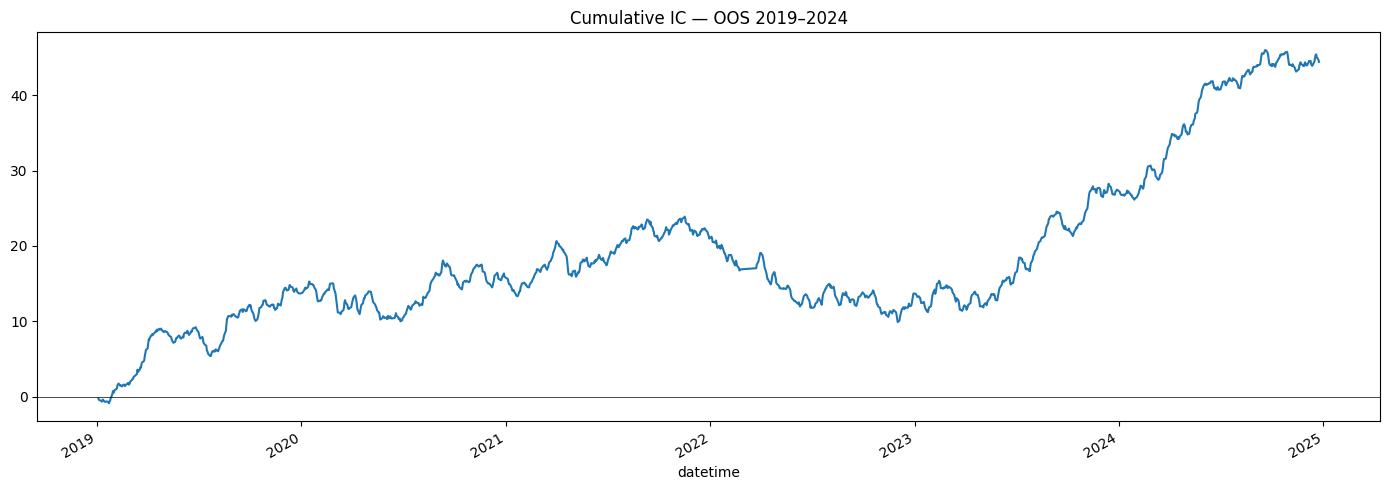

In [14]:
import matplotlib.pyplot as plt

ic_series = ic_full['ic_series']
ic_series.cumsum().plot(figsize=(14, 5),
                        title='Cumulative IC — OOS 2019–2024')
plt.axhline(0, color='k', lw=0.5)
plt.tight_layout()
plt.show()

Наличие положительной динамики в кумулятивном IC также свидетельствует в пользу наличия сигнала, хотя в 2022 году и была просадка (что, опять же, неудивительно).

Путём различных проверок мы убедились в статистической значимости сигнала. С такими данными вполне можно работать - сохраняем результат.

In [15]:
oos_df.to_parquet('data/oos_predictions_gbm.parquet')

Нашей дальнейшей задачей будет формирование портфеля.